# Vision Transformer (ViT) Fine-tuning Notebook
Bu notebook ön-eğitimli bir ViT modelini kendi veri kümeniz üzerinde fine-tune etmek için hazırlanmıştır.
NOT: Lütfen `dataset_dir` değişkenini veri kümenizin kök yoluna göre güncelleyin (ör. `C:/.../dataset`). Veri kümesi klasör yapısı `train/` ve `test/` alt klasörleri içermeli ve her biri sınıf alt-klasörleri barındırmalıdır.

## Imports
Bu hücre gerekli kütüphanelerin import edildiği yerdir.

In [2]:
# Imports
# Required libraries and utilities (plots, metrics, model helpers)
import os
import time
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

c:\Users\emirh\anaconda3\envs\pytorch-v1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration
Veri yolu ve eğitim hiperparametrelerini (batch size, epoch sayısı, learning rate vb.) buradan ayarlayın.

In [3]:
# Configuration
# Update dataset path and training hyperparameters below
dataset_dir = 'C:\\Users\\emirh\\Desktop\\Projects\\CNN\\DermiumNet\\dataset\\input_sk'
train_dir = os.path.join(dataset_dir, 'train')
test_dir = os.path.join(dataset_dir, 'test')
image_size = 224  # ViT tipik boyutu
batch_size = 32
num_workers = 4
epochs = 10  # önerilen aralık: 5-15
lr = 1e-4
weight_decay = 1e-4
model_name = 'vit_small_patch16_224'  # değiştirmek isterseniz: vit_tiny_*, vit_base_*, vb.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## Data Loading and Transforms
Görüntü dönüşümleri hazırlanır ve `ImageFolder` kullanılarak `DataLoader`lar oluşturulur.

In [4]:
# Data Loading and Transforms
# Prepare train/test transforms and create DataLoaders (ImageFolder expected)
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])
# Datasets: ImageFolder varsayımı
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)
num_classes = len(train_dataset.classes)
print('Num classes:', num_classes)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

Num classes: 8


## Model
Ön-eğitimli ViT modeli yüklenir ve sınıflandırma başlığı (`head`) `num_classes` olacak şekilde güncellenir.

In [5]:
# Model
# Load a pretrained ViT and adapt the classification head to `num_classes`
model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
model.to(device)
# Parametre sayısı (isteğe bağlı bilgi)
def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)
print('Trainable parameters:', count_parameters(model))

Trainable parameters: 21668744


c:\Users\emirh\anaconda3\envs\pytorch-v1\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\emirh\.cache\huggingface\hub\models--timm--vit_small_patch16_224.augreg_in21k_ft_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


## Optimizer and Loss
Optimizatör, kayıp fonksiyonu ve (isteğe bağlı) LR scheduler burada tanımlanır.

In [ ]:
# Optimizer and Loss
# Set optimizer, loss function and optional LR scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()
# Basit LR scheduler (isteğe bağlı değiştirebilirsiniz)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

## Training
Eğitim döngüsü: modelin fine-tune edildiği, epoch bazlı loss ve accuracy'nin kaydedildiği hücre.

In [7]:
# Training
# Fine-tune the model. This cell logs train/val loss and accuracy per epoch
train_losses = []
val_losses = []
train_accs = []
val_accs = []
start_time = time.time()
# Use test_loader as validation if you don't have a separate val set
val_loader = test_loader
for epoch in range(1, epochs+1):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    for images, labels in tqdm(train_loader, desc=f'Train Epoch {epoch}/{epochs}', leave=False):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        running_corrects += torch.sum(preds == labels).item()
    scheduler.step()
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    # Validation
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Val Epoch {epoch}/{epochs}', leave=False):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_running_corrects += torch.sum(preds == labels).item()
    val_loss = val_running_loss / len(val_loader.dataset)
    val_acc = val_running_corrects / len(val_loader.dataset)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f'Epoch {epoch} - Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Val Acc: {val_acc:.4f}')
total_time = time.time() - start_time
print(f'Training finished, elapsed time: {total_time:.1f} seconds')

Epoch 1 - Loss: 0.8300


Epoch 2 - Loss: 0.5552


Epoch 3 - Loss: 0.3942


Epoch 4 - Loss: 0.2819


Epoch 5 - Loss: 0.1917


Epoch 6 - Loss: 0.0632


Epoch 7 - Loss: 0.0295


Epoch 8 - Loss: 0.0311


Epoch 9 - Loss: 0.0347


Epoch 10 - Loss: 0.0256
Training finished, elapsed time: 1576.7 seconds


## Save Model
Model ağırlıklarını ve sınıf listesini çalışma dizinine kaydeder.

In [ ]:
# Save Model
# Persist fine-tuned model weights and class names to results/<model_name> directory
results_dir = os.path.join(os.getcwd(), 'results', model_name)
os.makedirs(results_dir, exist_ok=True)
out_path = os.path.join(results_dir, f'{model_name}_finetuned.pth')
torch.save({'model_state_dict': model.state_dict(), 'classes': train_dataset.classes}, out_path)
print('Saved model to', out_path)

Saved model to c:\Users\emirh\Desktop\Projects\SkinNet\vit_small_patch16_224_finetuned.pth


## Inference / Predictions
Test verisi üzerinde modelin tahminlerini toplayın; sonuçlar bir sonraki hücrede görselleştirilecek.

In [10]:
# Inference / Predictions
# Run the model on the test set and collect predictions for later analysis
import numpy as np
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Predicting'):
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.numpy().tolist())
# Convert to numpy arrays for downstream cells
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print('Collected', len(all_preds), 'predictions')

Evaluating: 100%|██████████| 159/159 [00:42<00:00,  3.70it/s]


Accuracy: 0.8161
Precision (macro): 0.7642
Recall (macro): 0.6777
F1-score (macro): 0.7090
Train/val history not found; graphs skipped.
Could not plot confusion matrix: name 'confusion_matrix' is not defined


## Results: Metrics and Visualizations
Bu hücre hesaplanan metrikleri yazdırır ve eğitim/validasyon eğrilerini ile karışıklık matrisini çizer.

Accuracy: 0.8161
Precision (macro): 0.7642
Recall (macro): 0.6777
F1-score (macro): 0.7090
Train/val history not found; graphs skipped.


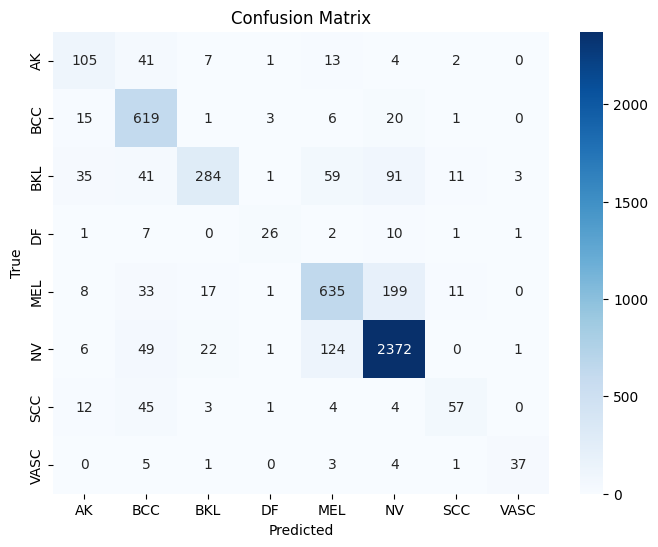

In [ ]:
# Results: Metrics and Visualizations
# Compute macro metrics and plot loss/accuracy curves and confusion matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print(f'Accuracy: {acc:.4f}')
print(f'Precision (macro): {prec:.4f}')
print(f'Recall (macro): {rec:.4f}')
print(f'F1-score (macro): {f1:.4f}')
# Plot train/val loss and accuracy if recorded
try:
    epochs_range = range(1, len(train_losses)+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs_range, train_losses, label='Train Loss')
    plt.plot(epochs_range, val_losses, label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss')
    plt.subplot(1,2,2)
    plt.plot(epochs_range, train_accs, label='Train Acc')
    plt.plot(epochs_range, val_accs, label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy')
    plt.tight_layout()
    # Ensure results directory exists and save the figure
    results_dir = os.path.join(os.getcwd(), 'results', model_name)
    os.makedirs(results_dir, exist_ok=True)
    plt.savefig(os.path.join(results_dir, 'loss_acc.png'))
    plt.show()
except NameError:
    print('Train/val history not found; graphs skipped.')
# Confusion matrix
try:
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.title('Confusion Matrix')
    # Save confusion matrix to results folder
    plt.savefig(os.path.join(results_dir, 'confusion_matrix.png'))
    plt.show()
except Exception as e:
    print('Could not plot confusion matrix:', e)